In [ ]:
Transformation, dropout, regularization 


[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: /usr/local/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Imports
###BEGIN library importing+
import tensorflow as tf
import matplotlib.pyplot as plt
###END library importing
from pathlib import Path
import tarfile
import urllib.request
import sys
import io
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn import set_config
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.svm import SVR
from sklearn.metrics import *
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import BaggingRegressor
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import (
    VotingRegressor,
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    StackingRegressor)
from tensorflow.keras.optimizers import SGD
import tensorflow as tf
from tensorflow.keras import Sequential, layers
import keras_tuner as kt

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge
from sklearn.model_selection import train_test_split
from code_files.train import train, train_in_batches, grid_search
from code_files.data_preperation import prepare_for_train
import pandas as pd
import numpy as np

In [9]:
# Load Dataset
df_amazon = pd.read_csv("../dataset/eda_amazon_sales_report.csv")
df_amazon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117123 entries, 0 to 117122
Data columns (total 24 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   Unnamed: 0                           117123 non-null  int64  
 1   Size                                 117123 non-null  int64  
 2   Qty                                  117123 non-null  int64  
 3   Amount                               117123 non-null  float64
 4   promotion-ids                        117123 non-null  int64  
 5   B2B                                  117123 non-null  int64  
 6   Status_Cancelled                     117123 non-null  bool   
 7   Status_Shipped                       117123 non-null  bool   
 8   Status_Shipped - Delivered to Buyer  117123 non-null  bool   
 9   Fulfilment_Amazon                    117123 non-null  bool   
 10  Fulfilment_Merchant                  117123 non-null  bool   
 11  ship-service-

In [10]:
# Transformation using yeo johnson 
from scipy import stats
df_amazon['Amount'], _ = stats.yeojohnson(df_amazon['Amount'])

In [11]:
# Split and Prepare for train
dftrain, dftest = train_test_split(df_amazon, test_size=0.1, random_state=42)
Xtrain_prepared, ytrain_prepared, Xtest_prepared, ytest_prepared = prepare_for_train(dftrain, dftest)

Xtrain_prepared, Xdev_prepared, ytrain_prepared, ydev_prepared = train_test_split(Xtrain_prepared, ytrain_prepared,
                                                                                  test_size=0.2, random_state=42)


print("Train shape: ", Xtrain_prepared.shape, ytrain_prepared.shape)
print("Dev shape: ", Xdev_prepared.shape, ydev_prepared.shape)
print("Test shape: ", Xtest_prepared.shape, ytest_prepared.shape)

Train shape:  (83216, 7) (83216,)
Dev shape:  (20804, 7) (20804,)
Test shape:  (11713, 7) (11713,)


In [ ]:
# # Helping function to build the model
# def build_model(hp):
#     # Hyperparameters to tune
#     n_hidden = hp.Int("n_hidden", min_value=2, max_value=32, default=4)  
#     n_neurons = hp.Int("n_neurons", min_value=100, max_value=1000, step=10)  
#     learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=0.1, sampling="log")  
#     optimizer_choice = hp.Choice("optimizer", values=["sgd", "RMSprop", "adam"]) 
#     activation_choice = hp.Choice("activation", values=["relu", "tanh", "selu","linear"])  
#     #batch_size = hp.Int("batch_size", min_value=16, max_value=128, step=16)  # Batch size range to tune

#     if optimizer_choice == "sgd":
#         optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
#     elif optimizer_choice == "RMSprop":
#         optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
#     else:
#         optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#     model = Sequential()
#     model.add(layers.Input(shape=(7,)))  

#     for _ in range(n_hidden):
#         model.add(layers.Dense(units=n_neurons, activation=activation_choice))

#     model.add(layers.Dense(1, activation="linear"))

#     model.compile(loss="mse", optimizer=optimizer, metrics=[tf.keras.metrics.RootMeanSquaredError()])
    
#     return model

# out_folder = "amazon"
# rnd_search_folder = "rnd_search"

# random_search_tuner = kt.RandomSearch(
#     build_model,
#     objective="val_loss",
#     max_trials=5,
#     overwrite=True,
#     directory=out_folder,
#     project_name=rnd_search_folder,
#     seed=42,
# )

# random_search_tuner.search(
#     Xtrain_prepared, ytrain_prepared,
#     epochs=10,
#     batch_size=128, 
#     validation_data=(Xdev_prepared, ydev_prepared)
# )

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# import keras_tuner as kt

# def build_model(hp):
#     # Hyperparameters to tune
#     n_hidden = hp.Int("n_hidden", min_value=1, max_value=5, default=2)  
#     n_neurons = hp.Int("n_neurons", min_value=32, max_value=512, step=32)  
#     learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=0.1, sampling="log")  
    
#     # Dropout rate as a new hyperparameter
#     dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    
#     optimizer_choice = hp.Choice("optimizer", values=["adam", "rmsprop", "sgd"]) 
#     activation_choice = hp.Choice("activation", values=["relu", "tanh", "selu"])  

#     # Optimizer selection
#     if optimizer_choice == "sgd":
#         optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
#     elif optimizer_choice == "rmsprop":
#         optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
#     else:
#         optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#     # Model construction
#     model = keras.Sequential()
#     model.add(layers.Input(shape=(Xtrain_prepared.shape[1],)))  

#     # Hidden layers with dropout
#     for _ in range(n_hidden):
#         model.add(layers.Dense(units=n_neurons, activation=activation_choice))
#         model.add(layers.Dropout(rate=dropout_rate))

#     model.add(layers.Dense(1, activation="linear"))

#     model.compile(
#         loss="mse", 
#         optimizer=optimizer, 
#         metrics=[tf.keras.metrics.RootMeanSquaredError()]
#     )
    
#     return model

# # Tuner setup
# tuner = kt.RandomSearch(
#     build_model,
#     objective="val_loss",
#     max_trials=50,  # Increased number of trials
#     overwrite=True,
#     directory="hyperparameter_tuning",
#     project_name="laptop_model",
#     seed=42
# )

# # Search for best hyperparameters
# tuner.search(
#     Xtrain_prepared, ytrain_prepared,
#     epochs=50,
#     batch_size=32, 
#     validation_split=0.2,
#     callbacks=[
#         tf.keras.callbacks.EarlyStopping(patience=5)
#     ]
# )

# # Get and print best hyperparameters
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
# print("Best Hyperparameters:")
# print(f"Number of hidden layers: {best_hps.get('n_hidden')}")
# print(f"Number of neurons: {best_hps.get('n_neurons')}")
# print(f"Learning rate: {best_hps.get('learning_rate')}")
# print(f"Dropout rate: {best_hps.get('dropout_rate')}")
# print(f"Optimizer: {best_hps.get('optimizer')}")
# print(f"Activation: {best_hps.get('activation')}")

# # Train the best model
# best_model = tuner.hypermodel.build(best_hps)
# history = best_model.fit(
#     Xtrain_prepared, ytrain_prepared,
#     validation_split=0.2,
#     epochs=100,
#     batch_size=32,
#     callbacks=[
#         tf.keras.callbacks.EarlyStopping(patience=10)
#     ]
# )

In [12]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, regularizers

# Helping functions
def build_model(hp):

    n_hidden = hp.Int("n_hidden", min_value=2, max_value=10, default=2)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=0.9,
                                      sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam", "adagrad", "rms", "adadelta", 
                                               "adamax", "nadam"])

    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == "adagrad":
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=learning_rate)
    elif optimizer == "rms": 
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer == "adadelta":
        optimizer = tf.keras.optimizers.Adadelta(learning_rate=learning_rate)
    elif optimizer == "adamax":
        optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
    elif optimizer == "ftrl":
        optimizer = tf.keras.optimizers.Ftrl(learning_rate=learning_rate)
    elif optimizer == "nadam": 
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())

    for _ in range(n_hidden):
        # Adding L2 regularization to Dense layers
        model.add(tf.keras.layers.Dense(
            units = hp.Int("n_neurons", min_value=100, max_value=900, step=50, sampling="log"),
            activation=hp.Choice("activation", values=["relu", "tanh", "selu", "linear", "swish", "softplus", "exponential"]),
            kernel_regularizer=regularizers.l2(hp.Float("l2_reg", min_value=1e-5, max_value=1e-1, sampling="log"))  # Regularization added
        ))
        model.add(layers.Dropout(rate=hp.Float("dropout_rate", min_value=0.1, max_value=0.9, step=0.1)))

    model.add(layers.Dense(1, activation='linear'))
    model.compile(
        loss='mse',
        optimizer=optimizer,
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )
    return model

########################

# Define parameter grid
out_folder = "amazon"
rnd_search_folder = "rnd_search"
random_search_tuner = kt.RandomSearch(
    build_model, objective="loss", max_trials=25, overwrite=True,
    directory=out_folder, project_name=rnd_search_folder, seed=42
)

random_search_tuner.search(Xtrain_prepared, ytrain_prepared, epochs=5, batch_size=64,
                           validation_data=(Xdev_prepared, ydev_prepared))

random_search_tuner.search_space_summary()

random_search_tuner.results_summary()

# Build the best model and retrain it
top3_models = random_search_tuner.get_best_models(num_models=3)

top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)

for i in range(len(top3_params)):
    print(top3_params[i].values)




Trial 25 Complete [00h 00m 07s]
loss: 3024.4345703125

Best loss So Far: 1491.9732666015625
Total elapsed time: 00h 03m 55s
Search space summary
Default search space size: 7
n_hidden (Int)
{'default': 2, 'conditions': [], 'min_value': 2, 'max_value': 10, 'step': 1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.9, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'sgd', 'conditions': [], 'values': ['sgd', 'adam', 'adagrad', 'rms', 'adadelta', 'adamax', 'nadam'], 'ordered': False}
n_neurons (Int)
{'default': None, 'conditions': [], 'min_value': 100, 'max_value': 900, 'step': 50, 'sampling': 'log'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'selu', 'linear', 'swish', 'softplus', 'exponential'], 'ordered': False}
l2_reg (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
dropout_rate (Float)
{'default

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 15 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


{'n_hidden': 2, 'learning_rate': 0.009276416723841687, 'optimizer': 'adam', 'n_neurons': 100, 'activation': 'swish', 'l2_reg': 0.04514107426881946, 'dropout_rate': 0.1}
{'n_hidden': 2, 'learning_rate': 0.00462287884982147, 'optimizer': 'nadam', 'n_neurons': 100, 'activation': 'softplus', 'l2_reg': 0.0003036527652974287, 'dropout_rate': 0.2}
{'n_hidden': 8, 'learning_rate': 0.0006154916238814045, 'optimizer': 'adamax', 'n_neurons': 100, 'activation': 'selu', 'l2_reg': 2.1103896995739087e-05, 'dropout_rate': 0.2}


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamax', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [13]:
#{'n_hidden': 12, 'n_neurons': 600, 'learning_rate': 0.00015872740971656704, 'optimizer': 'RMSprop', 'activation': 'relu'}

# Best Hyperparameters:
# Number of hidden layers: 1
# Number of neurons: 26
# Learning rate: 0.000017
# Dropout rate: 0.00
# Optimizer: sgd
# Activation: relu

# {'n_hidden': 2, 'learning_rate': 0.009276416723841687, 'optimizer': 'adam', 
# 'n_neurons': 100, 'activation': 'swish', 'l2_reg': 0.04514107426881946, 'dropout_rate': 0.1}


from tensorflow.keras import regularizers



optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.009276416723841687)

model1 = tf.keras.Sequential()

model1.add(tf.keras.layers.Input(shape=(7,)))  

model1.add(tf.keras.layers.Dense(100, activation="swish"))
model1.add(tf.keras.layers.Dropout(0.1))
model1.add(tf.keras.layers.Dense(100, activation="swish"))
model1.add(tf.keras.layers.Dropout(0.1))


model1.add(tf.keras.layers.Dense(1, activation="linear", kernel_regularizer=regularizers.l2(0.04514107426881946)))

model1.compile(loss="mse", optimizer=optimizer1, metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Print the model summary
model1.summary()

# Train the model
history = model1.fit(
    Xtrain_prepared, ytrain_prepared,
    epochs=500,     
    batch_size=64,      
    validation_data=(Xdev_prepared, ydev_prepared)
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 100)            │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,001 (42.97 KB)

 Trainable params: 11,001 (42.97 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 1s 651us/step - loss: 2746.8325 - root_mean_squared_error: 50.3530 - val_loss: 1518.0223 - val_root_mean_squared_error: 38.9421
Epoch 2/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 1s 578us/step - loss: 1510.2550 - root_mean_squared_error: 38.8368 - val_loss: 1510.2703 - val_root_mean_squared_error: 38.8254
Epoch 3/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 1s 577us/step - loss: 1539.9432 - root_mean_squared_error: 39.2001 - val_loss: 1528.9130 - val_root_mean_squared_error: 39.0461
Epoch 4/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 1s 575us/step - loss: 1517.5726 - root_mean_squared_error: 38.8918 - val_loss: 1518.8473 - val_root_mean_squared_error: 38.8877
Epoch 5/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 1s 576us/step - loss: 1495.3920 - root_mean_squared_error: 38.5788 - val_loss: 1604.8197 - val_root_mean_squared_error: 39.9653
Epoch 6/500
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - loss: 1501.6689 - root_mean_squared_error: 38.6520 - val_loss: 1520.2834 - val_root_me

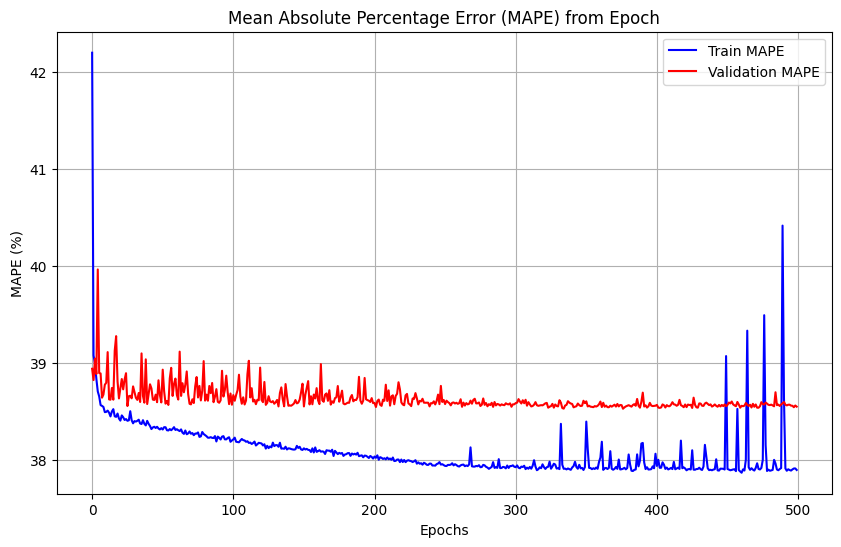

In [14]:
epochs = list(range(800, 2000))
plt.figure(figsize=(10, 6))
plt.plot(history.history['root_mean_squared_error'],label='Train MAPE',color='blue')
plt.plot(history.history['val_root_mean_squared_error'],label='Validation MAPE',color='red')
plt.title(f'Mean Absolute Percentage Error (MAPE) from Epoch')
plt.xlabel('Epochs')
plt.ylabel('MAPE (%)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# 5 evaluation the final model
#--- we will call the method evaluate() of model on the test set
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf

# Assuming you have test data
# X_test: the test input data
# y_test: the true target values for test data
y_pred = model1.predict(Xtest_prepared)

# MAE (Mean Absolute Error)
mae = mean_absolute_error(ytest_prepared, y_pred)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(ytest_prepared, y_pred))

# R² (R-squared)
r2 = r2_score(ytest_prepared, y_pred)

# Print the results
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step
MAE: 29.15711885911913
RMSE: 38.25805912023764
R²: 0.054792407417001865
